In [2]:
import ROOT
from IPython.display import Image

In [58]:
def fill_tree(treeName, fileName):
    """A simple helper function to fill a test tree: this makes the example stand-alone."""
    ### Create a RDF object with 10 rows ###
    df = ROOT.RDataFrame(10)
    ### Define creates a branch/column and Snapshot saves the columns in a TTree and a TFile ###
    ### Values seem to be initialized based on the index (rdfentry_) ###
    df.Define("b1", "static_cast<double>(rdfentry_)")\
      .Define("b2", "static_cast<int>(rdfentry_ * rdfentry_)")\
      .Snapshot(treeName, fileName)
    #print(df.Describe())
 
# We prepare an input tree to run on
fileName = "df001_introduction_py.root"
treeName = "myTree"
fill_tree(treeName, fileName)
 
 
# We read the tree from the file and create a RDataFrame, a class that
# allows us to interact with the data contained in the tree.
d = ROOT.RDataFrame(treeName, fileName)

#print(d.Describe())
''' 
 Operations on the dataframe
 We now review some *actions* which can be performed on the data frame.
 Actions can be divided into instant actions (e. g. Foreach()) and lazy
 actions (e. g. Count()), depending on whether they trigger the event 
 loop immediately or only when one of the results is accessed for the 
 first time. Actions that return "something" either return their result 
 wrapped in a RResultPtr or in a RDataFrame.
 But first of all, let us we define now our cut-flow with two strings.
 Filters can be expressed as strings. The content must be C++ code. The
 name of the variables must be the name of the branches. The code is
 just-in-time compiled.'''

cutb1 = 'b1 < 5.'      ### Notice that the strings are executable code and b1 referes to the branch/column names ###
cutb1b2 = 'b2 % 2 && b1 < 4.'
 
# `Count` action
# The `Count` allows to retrieve the number of the entries that passed the
# filters. Here we show how the automatic selection of the column kicks
# in in case the user specifies none.
entries1 = d.Filter(cutb1) \
            .Filter(cutb1b2) \
            .Count();
 
print('{} entries passed all filters'.format(entries1.GetValue()))
 
entries2 = d.Filter("b1 < 5.").Count();
print('{} entries passed all filters'.format(entries2.GetValue()))
 
# `Min`, `Max` and `Mean` actions
# These actions allow to retrieve statistical information about the entries
# passing the cuts, if any.
b1b2_cut = d.Filter(cutb1b2)
minVal = b1b2_cut.Min('b1')
maxVal = b1b2_cut.Max('b1')
meanVal = b1b2_cut.Mean('b1')
nonDefmeanVal = b1b2_cut.Mean("b2")
print('The mean is always included between the min and the max: {0} <= {1} <= {2}'.format(minVal.GetValue(), meanVal.GetValue(), maxVal.GetValue()))
 
# `Histo1D` action
# The `Histo1D` action allows to fill an histogram. It returns a TH1F filled
# with values of the column that passed the filters. For the most common
# types, the type of the values stored in the column is automatically
# guessed.
hist = d.Filter(cutb1).Histo1D('b1')
print('Filled h {0} times, mean: {1}'.format(hist.GetEntries(), hist.GetMean()))
 
# Express your chain of operations with clarity!
# We are discussing an example here but it is not hard to imagine much more
# complex pipelines of actions acting on data. Those might require code
# which is well organised, for example allowing to conditionally add filters
# or again to clearly separate filters and actions without the need of
# writing the entire pipeline on one line. This can be easily achieved.
# We'll show this re-working the `Count` example:
cutb1_result = d.Filter(cutb1);
print(f"Result of filtering for {cutb1} is {cutb1_result.AsNumpy()}")
cutb1b2_result = d.Filter(cutb1b2);
cutb1_cutb1b2_result = cutb1_result.Filter(cutb1b2)
 
# Now we want to count:
evts_cutb1_result = cutb1_result.Count()    ### Count() seems to count only rows, not rows*columns ###
evts_cutb1b2_result = cutb1b2_result.Count()
evts_cutb1_cutb1b2_result = cutb1_cutb1b2_result.Count()
 
print('Events passing cutb1: {}'.format(evts_cutb1_result.GetValue()))
print('Events passing cutb1b2: {}'.format(evts_cutb1b2_result.GetValue()))
print('Events passing both: {}'.format(evts_cutb1_cutb1b2_result.GetValue()))
 
# Calculating quantities starting from existing columns
# Often, operations need to be carried out on quantities calculated starting
# from the ones present in the columns. We'll create in this example a third
# column, the values of which are the sum of the *b1* and *b2* ones, entry by
# entry. The way in which the new quantity is defined is via a callable.
# It is important to note two aspects at this point:
# - The value is created on the fly only if the entry passed the existing
# filters.
# - The newly created column behaves as the one present on the file on disk.
# - The operation creates a new value, without modifying anything. De facto,
# this is like having a general container at disposal able to accommodate
# any value of any type.
# Let's dive in an example:
entries_sum = d.Define('sum', 'b2 + b1') \
               .Filter('sum > 4.2') \
               .Count()
print(entries_sum.GetValue())
 

2 entries passed all filters
5 entries passed all filters
The mean is always included between the min and the max: 1.0 <= 2.0 <= 3.0
Filled h 5.0 times, mean: 2.0
Result of filtering for b1 < 5. is {'b1': ndarray([0., 1., 2., 3., 4.]), 'b2': ndarray([ 0,  1,  4,  9, 16], dtype=int32)}
Events passing cutb1: 5
Events passing cutb1b2: 2
Events passing both: 2
8


In [52]:
npyb1 = d.AsNumpy(columns=["b1"])
npyb2 = d.AsNumpy(columns=["b2"])
print(npyb1)
print(npyb2)

{'b1': ndarray([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])}
{'b2': ndarray([ 0,  1,  4,  9, 16, 25, 36, 49, 64, 81], dtype=int32)}


Next,

In [69]:
d.Describe()

Dataframe from TChain myTree in file df002_dataModel_py.root

Property                Value
--------                -----
Columns in total            5
Columns from defines        0
Event loops run             2
Processing slots            1

Column                  Type                                                                            Origin
------                  ----                                                                            ------
tracks                  ROOT::VecOps::RVec<ROOT::Math::LorentzVector<ROOT::Math::PxPyPzE4D<double> >>   Dataset
tracks.fCoordinates.fT  ROOT::VecOps::RVec<Double_t>                                                    Dataset
tracks.fCoordinates.fX  ROOT::VecOps::RVec<Double_t>                                                    Dataset
tracks.fCoordinates.fY  ROOT::VecOps::RVec<Double_t>                                                    Dataset
tracks.fCoordinates.fZ  ROOT::VecOps::RVec<Double_t>                                   

In [59]:
# A simple helper function to fill a test tree: this makes the example stand-alone.
fill_tree_code = """
using FourVector = ROOT::Math::XYZTVector;
using FourVectorVec = std::vector<FourVector>;
using CylFourVector = ROOT::Math::RhoEtaPhiVector;
 
// A simple helper function to fill a test tree: this makes the example
// stand-alone.
void fill_tree(const char *filename, const char *treeName)
{
   const double M = 0.13957; // set pi+ mass
   TRandom3 R(1);
 
   auto genTracks = [&](){
      FourVectorVec tracks;
      const auto nPart = R.Poisson(15);
      tracks.reserve(nPart);
      for (int j = 0; j < nPart; ++j) {
         const auto px = R.Gaus(0, 10);
         const auto py = R.Gaus(0, 10);
         const auto pt = sqrt(px * px + py * py);
         const auto eta = R.Uniform(-3, 3);
         const auto phi = R.Uniform(0.0, 2 * TMath::Pi());
         CylFourVector vcyl(pt, eta, phi);
         // set energy
         auto E = sqrt(vcyl.R() * vcyl.R() + M * M);
         // fill track vector
         tracks.emplace_back(vcyl.X(), vcyl.Y(), vcyl.Z(), E);
      }
      return tracks;
   };
 
   ROOT::RDataFrame d(64);
   d.Define("tracks", genTracks).Snapshot(treeName, filename, {"tracks"});
}
"""
 
# We prepare an input tree to run on
fileName = "df002_dataModel_py.root"
treeName = "myTree"
ROOT.gInterpreter.Declare(fill_tree_code)
ROOT.fill_tree(fileName, treeName)
 
# We read the tree from the file and create a RDataFrame, a class that
# allows us to interact with the data contained in the tree.
d = ROOT.RDataFrame(treeName, fileName)
 
# Operating on branches which are collections of objects
# Here we deal with the simplest of the cuts: we decide to accept the event
# only if the number of tracks is greater than 8.
n_cut = "tracks.size() > 8"
nentries = d.Filter(n_cut).Count()
 
print("%s events passed all filters" % nentries.GetValue())
 
# Another possibility consists in creating a new column containing the
# quantity we are interested in.
# In this example, we will cut on the number of tracks and plot their
# transverse momentum.
 
getPt_code = """
using namespace ROOT::VecOps;
ROOT::RVecD getPt(const RVec<FourVector> &tracks)
{
   auto pt = [](const FourVector &v) { return v.pt(); };
   return Map(tracks, pt);
}
"""
ROOT.gInterpreter.Declare(getPt_code)
 
getPtWeights_code = """
using namespace ROOT::VecOps;
ROOT::RVecD getPtWeights(const RVec<FourVector> &tracks)
{
   auto ptWeight = [](const FourVector &v) { return 1. / v.Pt(); };
   return Map(tracks, ptWeight);
};
"""
ROOT.gInterpreter.Declare(getPtWeights_code)
 
augmented_d = (
    d.Define("tracks_n", "(int)tracks.size()")
    .Filter("tracks_n > 2")
    .Define("tracks_pts", "getPt( tracks )")
    .Define("tracks_pts_weights", "getPtWeights( tracks )")
)
 
# The histogram is initialised with a tuple containing the parameters of the
# histogram
trN = augmented_d.Histo1D(("", "", 40, -0.5, 39.5), "tracks_n")
trPts = augmented_d.Histo1D("tracks_pts")
trWPts = augmented_d.Histo1D("tracks_pts", "tracks_pts_weights")
 
c1 = ROOT.TCanvas()
trN.Draw()
c1.SaveAs("df002_trN.png")
 
c2 = ROOT.TCanvas()
trPts.Draw()
c2.SaveAs("df002_trPts.png")
 
c3 = ROOT.TCanvas()
trWPts.Draw()
c2.SaveAs("df002_trWPts.png")
 
print("Saved figures to df002_*.png")

62 events passed all filters
Saved figures to df002_*.png


Info in <TCanvas::Print>: png file df002_trN.png has been created
Info in <TCanvas::Print>: png file df002_trPts.png has been created
Info in <TCanvas::Print>: png file df002_trWPts.png has been created


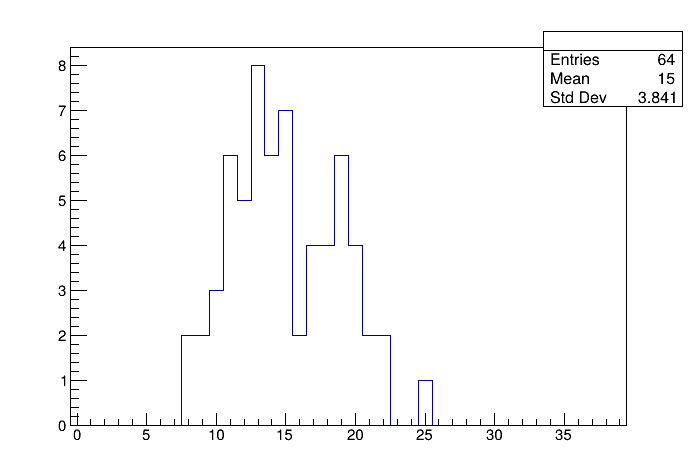

In [65]:
Image(filename='df002_trN.png')

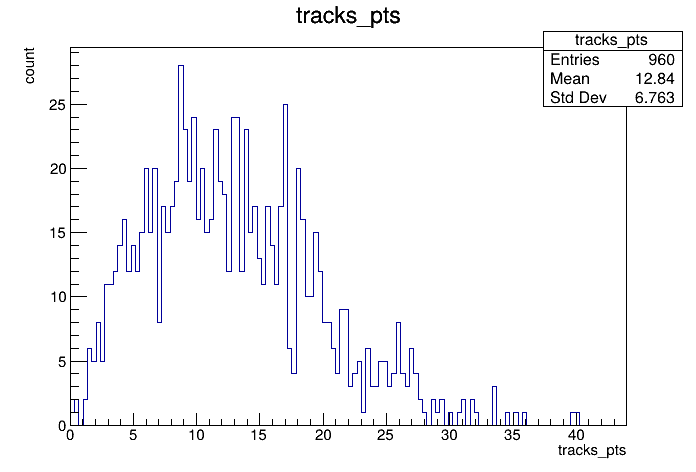

In [66]:
Image(filename='df002_trPts.png') 

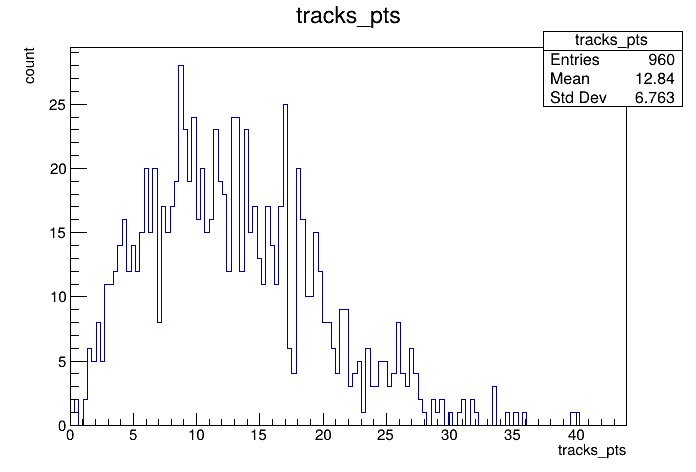

In [67]:
Image(filename='df002_trWPts.png') 